In [1]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np

import matplotlib.pyplot as plt

sys.path.append('/users/odarwish/abacusutils/')

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

In [2]:
import numpy as np
import numba

@numba.njit(parallel=True)
def calc_power_mu0_x_axis(delta_k, BoxSize, k_bin_edges = np.asarray(np.linspace(1e-3, 0.5, 200), dtype=np.float64), delta_k2 = None):
    """
    Compute the μ=0 power spectrum (perpendicular to x-axis) from a 3D Fourier field
    
    Parameters
    ----------
    delta_k : array_like
        Complex 3D Fourier field of shape (n1d, n1d, n1d//2+1)
    BoxSize : float
        Physical size of the simulation box
    k_bin_edges : array_like
        Edges of the k bins for binning the power spectrum
        
    Returns
    -------
    k_values : ndarray
        Mean k values in each bin
    power : ndarray
        Power spectrum for modes perpendicular to x-axis (μ=0)
    nmodes : ndarray
        Number of modes in each bin
    """
    if delta_k2 is None:
        delta_k2 = delta_k
        
    # Get dimensions
    n1d = delta_k.shape[0]
    middle = n1d // 2
    kzlen = n1d // 2 + 1
    
    # Fundamental mode
    kF = 2.0 * np.pi / BoxSize
    
    # Set up arrays for results
    Nk = len(k_bin_edges) - 1
    k_values = np.zeros(Nk, dtype=np.float64)
    power = np.zeros(Nk, dtype=np.float64)
    nmodes = np.zeros(Nk, dtype=np.int64)
    
    # Convert bin edges to grid units
    kedges = np.zeros_like(k_bin_edges)
    for i in range(len(k_bin_edges)):
        kedges[i] = k_bin_edges[i] / kF
    
    # Loop over all independent modes in the Fourier grid
    for kxx in numba.prange(n1d):
        # Convert array index to k-space value
        kx = kxx - n1d if kxx > middle else kxx
        
        # For μ=0 with x-axis as line of sight, we need kx=0
        if kx != 0:
            continue
            
        for kyy in range(n1d):
            ky = kyy - n1d if kyy > middle else kyy
            
            for kzz in range(kzlen):
                kz = kzz  # kz is always positive due to rfft
                
                # Handle symmetry planes
                if kz == 0 or (kz == middle and n1d % 2 == 0):
                    if ky < 0:
                        continue
                    elif ky == 0 or (ky == middle and n1d % 2 == 0):
                        if kz < 0:
                            continue
                
                # Compute |k| of the mode for binning
                k_perp = np.sqrt(ky*ky + kz*kz)
                
                # Find the bin for this k value
                bin_idx = -1
                for b in range(Nk):
                    if k_perp >= kedges[b] and k_perp < kedges[b+1]:
                        bin_idx = b
                        break
                
                if bin_idx >= 0:
                    # Compute the power
                    #mode_power = np.abs(delta_k[kxx, kyy, kzz])**2
                    mode_power = np.real(delta_k[kxx, kyy, kzz] * np.conj(delta_k2[kxx, kyy, kzz]))
                    
                    # Account for complex conjugate modes
                    mode_count = 1 if (kz == 0 or (kz == middle and n1d % 2 == 0)) else 2
                    
                    # Add to the bin
                    nmodes[bin_idx] += mode_count
                    power[bin_idx] += mode_power * mode_count
                    k_values[bin_idx] += k_perp * kF * mode_count
    
    # Normalize the results
    for i in range(Nk):
        if nmodes[i] > 0:
            power[i] = power[i] / nmodes[i] * BoxSize**3  # Proper units
            k_values[i] = k_values[i] / nmodes[i]
    
    return k_values, power#, nmodes

In [3]:
from abacusnbody.analysis.power_spectrum import calc_power
from abacusnbody.data import read_abacus
from pathlib import Path

In [4]:
scratch = "/capstor/scratch/cscs/odarwish/ABACUS/"

In [5]:
z = 0.5

In [6]:
pos = np.load(scratch+"pos_file.npy")

In [7]:
box = 2000
nthread = 256
ngrid = 576#*2

In [8]:
interlaced = True
compensated = True
paste = 'TSC'
nbins_mu = 4
logk = False
k_hMpc_max = np.pi * ngrid / box + 1.0e-6
nbins_k = ngrid // 2
nthread = 128
dtype = np.float32

In [9]:
poles = [0]

kmin_vol = 2*np.pi/box

power_alt = calc_power(
    pos["pos"],
    box,
    nbins_k,
    nbins_mu,
    k_hMpc_max,
    logk,
    paste,
    ngrid,
    compensated,
    interlaced,
    poles=poles,
)

In [10]:
with open('config_abacus.yaml', 'r') as f:
    config = yaml.safe_load(f)
gen_nl_power = np.loadtxt(config['power_spectrum']['nonlinear'])

(0.0031415926535897933, 36.8198059600527)

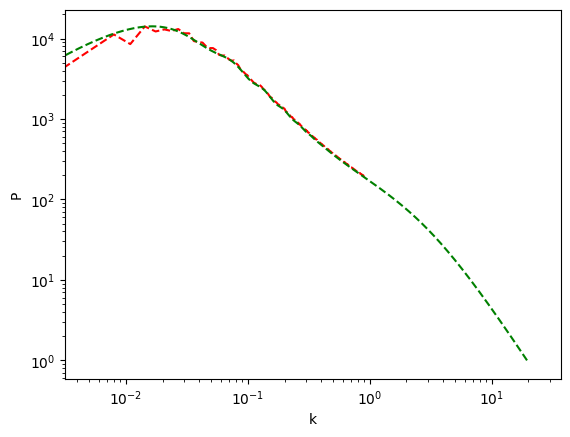

In [11]:
index = 1

plt.loglog(power_alt['k_avg'][:, index], power_alt['power'][:, index], ls = "--", c = "r")

plt.plot(gen_nl_power[:,0], gen_nl_power[:,1], ls='--', c='g')

plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol)
#plt.ylim(100)

In [12]:
from abacusnbody.analysis import tsc
delta = tsc.tsc_parallel(pos['pos'], ngrid, box, nthread=nthread)
delta /= np.mean(delta, dtype=np.float64)
delta -= 1.

In [13]:
delta_shifted = tsc.tsc_parallel(pos['pos']+box/2, ngrid, box, nthread=nthread)
delta_shifted /= np.mean(delta_shifted, dtype=np.float64)
delta_shifted -= 1.

In [14]:
del pos

In [15]:
from scipy.fft import rfftn, irfftn, fftfreq, rfftfreq
def get_kgrid(N):
    return 2 * np.pi * np.stack(
        np.meshgrid(
            fftfreq(N, d=box/N), fftfreq(N, d=box/N), rfftfreq(N, d=box/N),
            indexing='ij',
            )
        )

In [16]:
#k = (fftfreq(nmesh, d=d) * 2.0 * np.pi).astype(np.float32)  # h/Mpc

W = ps.get_W_compensated(box, ngrid, paste, interlaced)

In [17]:
kgrid = get_kgrid(delta.shape[0])
print(kgrid.shape)
kmag = (kgrid**2).sum(axis=0)**0.5
print(kmag.shape)

(3, 576, 576, 289)
(576, 576, 289)


In [18]:
field_fft = rfftn(delta, overwrite_x=False, workers=nthread)
field_fft *= 1 / delta.size

In [19]:
inv_size = dtype(1 / delta.size)
field_fft = rfftn(delta, overwrite_x=True, workers=nthread)
ps._normalize(field_fft, inv_size, nthread=nthread)
field_fft /= (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
)

In [20]:
poles = np.array([0])
k_max = np.pi * ngrid / box
mubins = nbins_mu
logk = False
kbins = ngrid
kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)

In [21]:
power_delta = calc_pk_from_deltak(
    field_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [22]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

(0.0031415926535897933, 36.8198059600527)

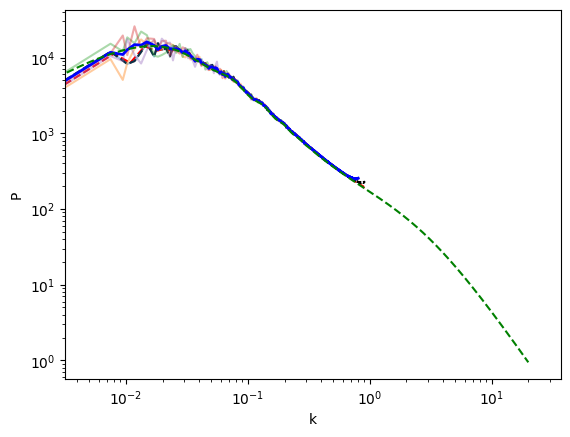

In [23]:
index = 1

plt.loglog(power_alt['k_avg'][:, index], power_alt['power'][:, index], ls = "--", c = "r")

#plt.loglog(power_field['k_avg'][:, index], power_field['power'][:, index], ls = "", c = "r", marker = "o")


plt.loglog(power_delta['k_avg'][:, index], power_delta['power'][:, index], ls = "--", c = "k")

idxs = [0, 1, 2, 3, 4]
mean = 0
for sim_idx in idxs:
    power_product_file = np.load(output_dir/f'power_delta_{sim_idx:03}.npy', allow_pickle = True).item()
    plt.plot(power_product_file['k_avg'][:, index], power_product_file['power'][:, index], alpha = 0.4)
    mean += power_product_file['power'][:, index]
plt.plot(power_product_file['k_avg'][:, index], mean/len(idxs), lw = 2, color = "blue")

plt.plot(gen_nl_power[:,0], gen_nl_power[:,1], ls='--', c='g')

plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol)
#plt.ylim(100)

In [24]:
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp

sim_name = config['sim_params']['sim_name']
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)

z_ic = meta['InitialRedshift']

Dz = meta['GrowthTable']
ztarget = 0.5
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

gen_power = np.loadtxt(config['power_spectrum']['linear'])


In [25]:
D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic]
D_ratio

59.91148545808563

In [26]:
sim_name = config['sim_params']["sim_name"]
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)
del ic

In [27]:
disp_x, disp_y, disp_z = load_disp(ic_dir, sim_name, ngrid)
f_growth = 0.0
disp_pos = np.zeros((ngrid**3, 3), np.float32)
disp_pos[:, 0] = disp_x[:, :, :].flatten() * D_ratio
disp_pos[:, 1] = disp_y[:, :, :].flatten() * D_ratio
disp_pos[:, 2] = disp_z[:, :, :].flatten() * D_ratio * (1 + f_growth)
grid_x, grid_y, grid_z = np.meshgrid(
            np.arange(ngrid, dtype=np.float32) / ngrid,
            np.arange(ngrid, dtype=np.float32) / ngrid,
            np.arange(ngrid, dtype=np.float32) / ngrid,
            indexing='ij',
        )
grid_x = grid_x.flatten()
grid_y = grid_y.flatten()
grid_z = grid_z.flatten()

disp_pos[:, 0] += grid_x
disp_pos[:, 1] += grid_y
disp_pos[:, 2] += grid_z
del grid_x, grid_y, grid_z, disp_x, disp_y, disp_z 
Lbox = meta['BoxSize']
disp_pos *= Lbox

In [28]:
ic = load_dens(ic_dir, sim_name, ngrid)
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size
del ic

In [29]:
from abacusnbody.analysis.power_spectrum import (
    calc_pk_from_deltak,
    get_field_fft,
    get_k_mu_edges,
    get_W_compensated,
)

field_fft_disp_base = get_field_fft(
            disp_pos, Lbox, ngrid, paste, None, W, compensated, interlaced
            )


field_fft_disp = get_field_fft(
            disp_pos-Lbox/2, Lbox, ngrid, paste, None, W, compensated, interlaced
            )

del disp_pos

In [30]:
power_disp = calc_pk_from_deltak(
    field_fft_disp,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [31]:
power_ic = calc_pk_from_deltak(
    ic_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

(0.0031415926535897933, 166.23669538741154)

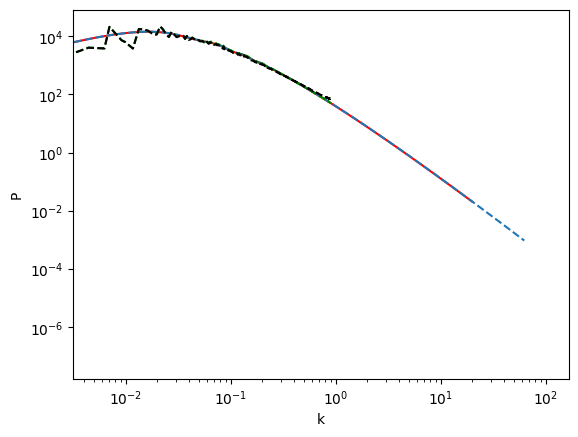

In [32]:
index = 0


plt.plot(gen_power[:,0], gen_power[:,1], ls='-', c = 'r')

plt.loglog(k, linear_pk, ls = "--")

plt.loglog(power_ic['k_avg'][:, index], power_ic['power'][:, index]*D_ratio**2, ls = "--", c = "g")

plt.plot(power_disp['k_avg'][:, index], power_disp['power'][:, index], ls = "--", color = "k")

plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol)
#plt.ylim(100)

In [33]:
#ic = load_dens(ic_dir, sim_name, ngrid)

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
gen_power = np.loadtxt(config['power_spectrum']['linear'])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']

In [34]:
from jax import numpy as jnp

def get_growth_rec(fft_field, box = 2000, return_field = False, filter_field = False, extra_fft_factor = 1, real = False):
    
    Ptot_interp = jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
    gen_power = np.loadtxt(config['power_spectrum']['linear'])
    Plin_interp = jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
    
    kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']
    selection = (kmag>=kmin) & (kmag<=kmax)
    #selection = gauss_filter(kmag)

    if filter_field:
        fft_field = filt(fft_field, ngrid, box, kmax)
    
    delta_A = fft_field*1/Ptot_interp*selection*extra_fft_factor
    
    delta_B = fft_field*1/Ptot_interp*Plin_interp*selection*extra_fft_factor
    
    delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)
    delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)
    
    product = 4*delta_A_real*delta_B_real*17/21*delta_B.size
    
    product_fft = rfftn(product, overwrite_x=False, workers=nthread)
    #product_fft *= 1 / product.size

    kbins = ngrid
    mubins = 4
    kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)
    
    power_product = calc_pk_from_deltak(
        product_fft,
        box,
        kbins,
        mubins,
        field2_fft=None,
        poles=poles,
        squeeze_mu_axis=True,
        nthread=128,
    )

    if return_field:
        if not real:
            return power_product, product_fft
        else:
            return power_product, product_fft, product
    else:
        return power_product

In [35]:
ic_growth = get_growth_rec(ic_fft*D_ratio)
f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )
#ic_growth_W = get_growth_rec(ic_fft/f)
#ic_growth_3000 = get_growth_rec(ic_fft*ic.size, 3000)
#ic_growth_4000 = get_growth_rec(ic_fft, 4000)

In [36]:
f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
    )

In [37]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']
out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()
out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()



kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

Ks = np.linspace(k_min_analysis, k_max_analysis, k_samples)

In [40]:
ngrid ** 3 / box**3, ngrid*box

(0.023887872, 1152000)

(0.006, 0.2)

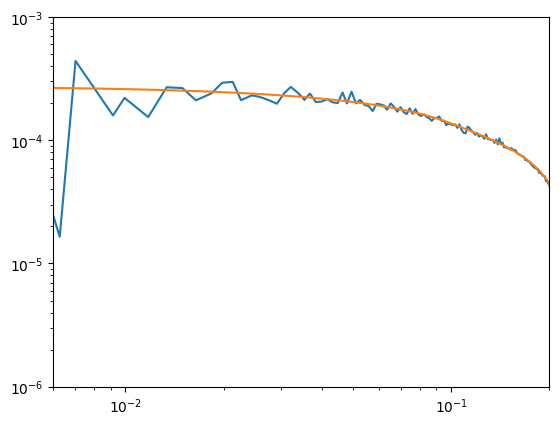

In [39]:
key = "g"
kinds = ["s", "t", "g"]
N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]

index = 0
#plt.loglog(Ks, v, ls = "--")
plt.plot(ic_growth["k_avg"][:, index], ic_growth["power"][:, index])
#plt.plot(ic_growth_W["k_avg"][:, index], ic_growth_W["power"][:, index])

#plt.loglog(kn, powergn, marker = "o", ls = "", alpha = 0.4)


plt.loglog(Ks, N**-1)

#plt.loglog(kn_box, powergn_box/1.5**(2*3/2))

#plt.loglog(Ks, (np.interp(Ks, kn, powergn)*N**2)**-1.)

#plt.plot(ic_growth_3000["k_avg"][:, index], ic_growth_3000["power"][:, index])
#plt.plot(ic_growth_4000["k_avg"][:, index], ic_growth_4000["power"][:, index])
#plt.ylim(1e3, 1e5)
plt.ylim(1e-6, 1e-3)
plt.xlim(6e-3, 2e-1)

In [41]:
from abacusnbody.hod.zcv.ic_fields import filter_field as filt


def get_shift_rec(fft_field, box = 2000, j_factor = 1, filter_field = False):

    kgrid = get_kgrid(delta.shape[0])
    
    kmag = ((kgrid**2).sum(axis=0))**0.5
    
    Ptot_interp = jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
    gen_power = np.loadtxt(config['power_spectrum']['linear'])
    Plin_interp = jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
    
    kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']
    
    selection = (kmag>=kmin) & (kmag<=kmax)
    #selection = gauss_filter(kmag)

    if filter_field:
        fft_field = filt(fft_field, ngrid, box, kmax)
    
    delta_A = fft_field*1/Ptot_interp*selection #IVF FIELD
    delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)

    delta_B = fft_field*1/Ptot_interp*Plin_interp*selection #WF FIELD

    inv_kmag_2 = 1/kmag**2
    inv_kmag_2[kmag == 0] = 0
    
    term = 0.
    tot_1 = 0.
    tot_2 = 0.
    for i in range(3):

        term_1 = delta_B*j_factor*kgrid[i]*inv_kmag_2
        term_2 = delta_B*j_factor*kgrid[i]

        term_1_real = irfftn(term_1, overwrite_x=True, workers=nthread)
        term_2_real = irfftn(term_2, overwrite_x=True, workers=nthread)
        
        product_1 = term_1_real*delta_A_real
        term_1 = rfftn(product_1, overwrite_x=False, workers=nthread)
        term_1 *= j_factor*kgrid[i]

        product_2 = term_2_real*delta_A_real
        term_2 = rfftn(product_2, overwrite_x=False, workers=nthread)
        term_2 *= j_factor*kgrid[i]*inv_kmag_2

        term += (term_1+term_2)*delta_A_real.size
        tot_1 += term_1
        tot_2 += term_2
    
    #delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)
    #product = delta_A_real*delta_B_real*17/21*delta_B.size
    #product_fft = rfftn(product, overwrite_x=False, workers=nthread)
    #product_fft *= 1 / product.size

    kbins = ngrid
    mubins = 4
    kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)
    
    power_product = calc_pk_from_deltak(
        term,
        box,
        kbins,
        mubins,
        field2_fft=None,
        poles=poles,
        squeeze_mu_axis=True,
        nthread=128,
    )

    return power_product, term

In [42]:
shift_j, term = get_shift_rec(ic_fft*D_ratio, j_factor = 1j, filter_field = False)

/tmp/ipykernel_173177/2979425112.py:27: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


(0.006, 0.2)

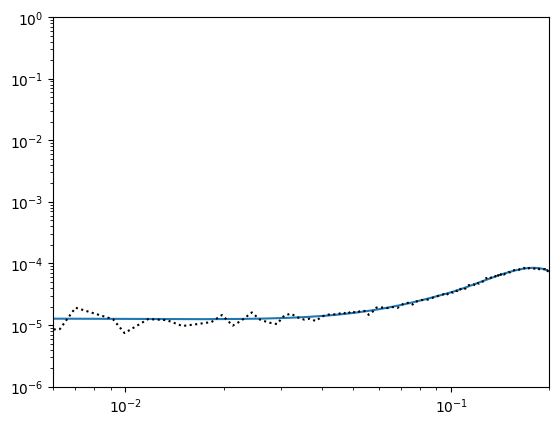

In [43]:
out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()

key = "s"
kinds = ["s", "t", "g"]
N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]

index = 0
plt.loglog(Ks, N**-1)

#plt.loglog(kn, powersn, marker = "o", ls = "", alpha = 0.4)
#plt.loglog(kn, powersn_A, marker = "o", ls = "", alpha = 0.4)
#plt.loglog(kn, powersn_B, marker = "o", ls = "", alpha = 0.4)

#plt.plot(ic_shift["k_avg"][:, index], ic_shift["power"][:, index]*size**2)
#plt.plot(ic_shift["k_avg"][:, index], ic_shift_1["power"][:, index]*size**2)
#plt.plot(ic_shift["k_avg"][:, index], ic_shift_2["power"][:, index]*size**2)

plt.plot(shift_j["k_avg"][:, index], shift_j["power"][:, index], ls = ":", color = "black")

#plt.loglog(kn, powers_rfield, marker = "o", ls = "", alpha = 0.4)

"""
key = "a"
Naa = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]
plt.loglog(Ks, Naa**-1, ls = "--")
#plt.loglog(Ks, v, ls = "--")


key = "b"
Nbb = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]
#plt.loglog(Ks, v, ls = ":")
plt.loglog(Ks, Nbb**-1, ls = ":")

plt.loglog(Ks, Naa**-1+Nbb**-1)
"""

plt.ylim(1e-6, 1)
plt.xlim(6e-3, 2e-1)

In [44]:
from abacusnbody.hod.zcv.ic_fields import filter_field as filt


def get_tidal_rec(fft_field, box = 2000, j_factor = 1, filter_field = False):

    kgrid = get_kgrid(delta.shape[0])
    
    kmag = ((kgrid**2).sum(axis=0))**0.5
    
    Ptot_interp = jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
    gen_power = np.loadtxt(config['power_spectrum']['linear'])
    Plin_interp = jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
    
    kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']
    
    selection = (kmag>=kmin) & (kmag<=kmax)
    #selection = gauss_filter(kmag)

    if filter_field:
        fft_field = filt(fft_field, ngrid, box, kmax)
    
    delta_A = fft_field*1/Ptot_interp*selection #IVF FIELD
    delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)

    delta_B = fft_field*1/Ptot_interp*Plin_interp*selection #WF FIELD

    inv_kmag_2 = 1/kmag**2
    inv_kmag_2[kmag == 0] = 0
    
    term = 0.
    tot_1 = 0.
    tot_2 = 0.
    for i in range(3):

        term_1 = delta_B*j_factor*kgrid[i]*inv_kmag_2
        term_2 = delta_B*j_factor*kgrid[i]

        term_1_real = irfftn(term_1, overwrite_x=True, workers=nthread)
        term_2_real = irfftn(term_2, overwrite_x=True, workers=nthread)
        
        product_1 = term_1_real*delta_A_real
        term_1 = rfftn(product_1, overwrite_x=False, workers=nthread)
        term_1 *= j_factor*kgrid[i]

        product_2 = term_2_real*delta_A_real
        term_2 = rfftn(product_2, overwrite_x=False, workers=nthread)
        term_2 *= j_factor*kgrid[i]*inv_kmag_2

        term += (term_1+term_2)*delta_A_real.size
        tot_1 += term_1
        tot_2 += term_2
    
    #delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)
    #product = delta_A_real*delta_B_real*17/21*delta_B.size
    #product_fft = rfftn(product, overwrite_x=False, workers=nthread)
    #product_fft *= 1 / product.size

    kbins = ngrid
    mubins = 4
    kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)
    
    power_product = calc_pk_from_deltak(
        term,
        box,
        kbins,
        mubins,
        field2_fft=None,
        poles=poles,
        squeeze_mu_axis=True,
        nthread=128,
    )

    return power_product, term

### Use the non-linear field

In [45]:
#delta = tsc.tsc_parallel(pos['pos'], ngrid, box, nthread=nthread)
#delta /= np.mean(delta, dtype=np.float64)
#delta -= 1.

In [46]:
field_fft = rfftn(delta, overwrite_x=False, workers=nthread)
#field_fft *= 1 / delta.size

In [47]:
ff = lambda size: np.exp(1j*np.random.uniform(0., 2.*np.pi, size = size))
field_fft_rand = field_fft*ff(field_fft.size).reshape(field_fft.shape)
field_fft_rand[0, 0, 0] = 0

In [48]:
field_fft_rand[0, 0, 0], field_fft[0, 0, 1]

(0j, (202647.84+213728.58j))

In [49]:
kbins = ngrid
mubins = 4
kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)


pa = calc_pk_from_deltak(
    field_fft/f,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

pb = calc_pk_from_deltak(
    field_fft_rand/f,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

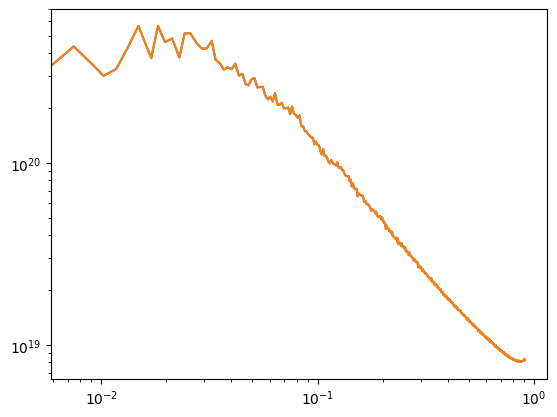

In [50]:
index = 1
plt.loglog(pa["k_avg"][:, index], pa["power"][:, index])
plt.loglog(pb["k_avg"][:, index], pb["power"][:, index])

In [51]:
field_shifted_fft = rfftn(delta_shifted, overwrite_x=False, workers=nthread)

In [52]:
ic_growth_nl, growth_field = get_growth_rec(field_fft, return_field = True)

In [53]:
ic_growth_nl_filt, growth_field_filt = get_growth_rec(field_fft/f, return_field = True, filter_field = False)


ic_growth_nl_disp, growth_field_disp = get_growth_rec(field_fft_disp, return_field = True)

In [54]:
ic_growth_nl_rand, growth_field_rand = get_growth_rec(field_fft_rand, return_field = True)

In [55]:
ic_growth_nl_shifted, growth_field_shifted = get_growth_rec(field_shifted_fft, return_field = True)

In [56]:
np.nanmean(ic_growth_nl['power']), np.nanmean(ic_growth_nl_rand['power'])

(3.5801852e+31, 3.449929e+31)

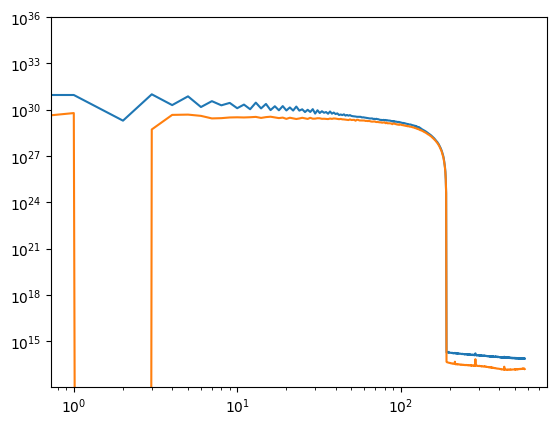

In [57]:
plt.loglog(ic_growth_nl['power'][:, 0])
plt.loglog(ic_growth_nl_rand['power'][:, 3])

In [58]:
#cross
kbins = ngrid
mubins = 4
kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, logk)

power_product_linear = calc_pk_from_deltak(
    growth_field,
    box,
    kbins,
    mubins,
    field2_fft=ic_fft*D_ratio,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [59]:
power_product_linear_shifted = calc_pk_from_deltak(
    growth_field_shifted,
    box,
    kbins,
    mubins,
    field2_fft=ic_fft*D_ratio,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [60]:
power_product_nl_linear = calc_pk_from_deltak(
    field_fft,
    box,
    kbins,
    mubins,
    field2_fft=field_fft_disp,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

power_product_growth_linear = calc_pk_from_deltak(
    growth_field,
    box,
    kbins,
    mubins,
    field2_fft=field_fft_disp,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

power_product_growth_linear_filt = calc_pk_from_deltak(
    growth_field_filt,
    box,
    kbins,
    mubins,
    field2_fft=field_fft_disp,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

(1000.0, 22435.0803887364)

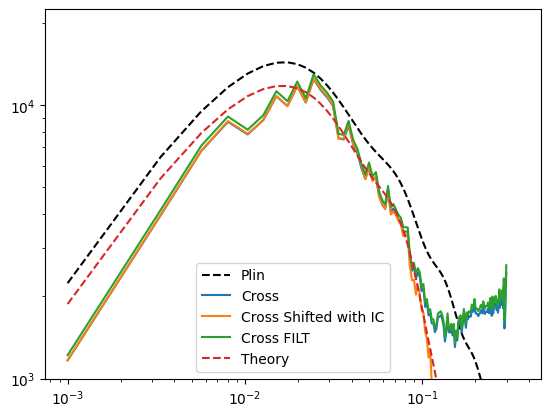

In [61]:
key = "g"
kinds = ["s", "t", "g"]

N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]


#plt.loglog(power_product_nl_linear["k_avg"][:, index], power_product_nl_linear["power"][:, index]/ delta.size)
linear_pk_interp = jnp.interp(Ks, k, linear_pk)
plt.loglog(Ks, linear_pk_interp, "k--", label = "Plin")


v = np.interp(Ks, power_product_growth_linear["k_avg"][:, index], power_product_growth_linear["power"][:, index])
plt.loglog(Ks, v*np.array(N)/delta.size**2, label = "Cross")


v = np.interp(Ks, power_product_linear_shifted["k_avg"][:, index], power_product_linear_shifted["power"][:, index])
plt.loglog(Ks, v*np.array(N)/delta.size**2, label = "Cross Shifted with IC")


v = np.interp(Ks, power_product_growth_linear_filt["k_avg"][:, index], power_product_growth_linear_filt["power"][:, index])
plt.loglog(Ks, v*np.array(N)/delta.size**2, label = "Cross FILT")

bias = 0
for kk in kinds:
    bias += (N*out_normalization_AB[(key, kk)])

linear_pk_interp = jnp.interp(Ks, k, linear_pk)
plt.loglog(Ks, bias*linear_pk_interp, ls = "--", label = "Theory")

#plt.loglog(Ks, bias**2*linear_pk_interp+N, ls = "--", label = "Theory Auto")

plt.legend()
plt.ylim(1e3)


In [62]:
power_product_disp = calc_pk_from_deltak(
    ic_fft*D_ratio,#field_fft_disp/f,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [63]:
mubins

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [64]:
poles

array([0])

In [65]:
Nmu = 100
pa = calc_pk_from_deltak(
    growth_field/f,
    box,
    kbins,
    np.linspace(0.0, 1.0, Nmu+1),
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=False,
    nthread=128,
)

In [66]:
power_growth, _, growth_real = get_growth_rec(field_fft, return_field = True, real = True)
del _

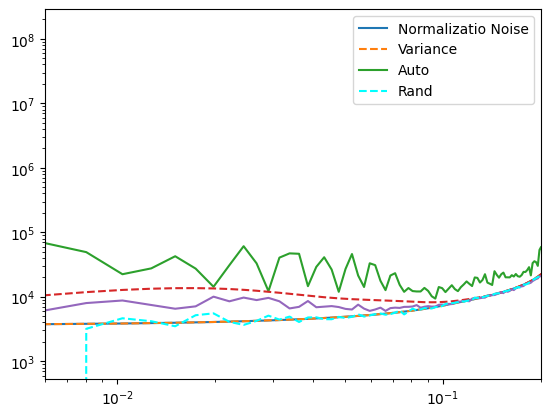

In [67]:
key = "g"
kinds = ["s", "t", "g"]

N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]

plt.plot(Ks, N, label = "Normalizatio Noise")
plt.plot(Ks, N**2*v, label = "Variance", ls = "--")

factor = 1/delta.size**2

#plt.loglog(power_product_nl_linear["k_avg"][:, index], 16*power_product_nl_linear["power"][:, index]/delta.size**4)

a, b = ic_growth_nl["k_avg"][:, 0], np.nan_to_num(pa["power"][:, 0]*factor**2)
b[0] = 0.
b = b.astype(float)
value = np.interp(Ks, a, b)*N**2.
plt.loglog(Ks, value, label = "Auto")

a, b = ic_growth_nl_filt["k_avg"][:, index], np.nan_to_num(ic_growth_nl_filt["power"][:, index]*factor**2)
b[0] = 0.
b = b.astype(float)
value = np.interp(Ks, a, b)*N**2.
#plt.loglog(Ks, value, label = "FILT")

bias = 0
for kk in kinds:
    bias += (N*out_normalization_AB[(key, kk)])

linear_pk_interp = jnp.interp(Ks, k, linear_pk)
plt.loglog(Ks, bias**2*linear_pk_interp+N, ls = "--")

a, b = ic_growth_nl_disp["k_avg"][:, index], np.nan_to_num(ic_growth_nl_disp["power"][:, index])
b[0] = 0.
b = b.astype(float)
value = np.interp(Ks, a, b)*N**2.
plt.loglog(Ks, value)

power_product_disp

a, b = ic_growth_nl_disp["k_avg"][:, index], np.nan_to_num(ic_growth_nl_disp["power"][:, index])*factor**2
b[0] = 0.
b = b.astype(float)
value = np.interp(Ks, a, b)*N**2.
#plt.loglog(Ks, value, ls = "--")

#plt.plot(Ks, linear_pk_interp+N, "k")


a, b = ic_growth_nl_rand["k_avg"][:, 0], np.nan_to_num(ic_growth_nl_rand["power"][:, index])*factor**2
b[0] = 0.
b = b.astype(float)
value = np.interp(Ks, a, b)*N**2.
plt.loglog(Ks, value, ls = "--", label = "Rand", color = "cyan")

#plt.ylim(1e-6, 1)
plt.xlim(6e-3, 2e-1)

plt.legend()


In [ ]:
"""sys.path.append('/users/odarwish/nbodykit/')
import nbodykit
from nbodykit.lab import ArrayCatalog
from nbodykit.source.mesh.field import FieldMesh
import nbodykit
from nbodykit.lab import ArrayCatalog, ArrayMesh
from pmesh.pm import ParticleMesh
import jax.numpy as jnp

delta_pos = tsc.tsc_parallel(disp_pos, ngrid, box, nthread=nthread)
delta_pos /= np.mean(delta_pos, dtype=np.float64)
delta_pos -= 1.

pm = ParticleMesh(BoxSize=box, Nmesh=[ngrid]*3)
real_field = pm.create(type='real')
real_field[...] = delta_pos  # fill the mesh
delta_mesh = FieldMesh(real_field)
from nbodykit.algorithms.fftpower import FFTPower

r = FFTPower(delta_mesh, mode='1d')
Pk = r.power

# Extract k and P(k)
kn = Pk['k']
powergn = Pk['power'].real
modesn = Pk['modes']"""

In [ ]:

disp_x, disp_y, disp_z = load_disp(ic_dir, sim_name, ngrid)
f_growth = 0.0
disp_pos = np.zeros((ngrid**3, 3), np.float32)
disp_pos[:, 0] = disp_x[: :, :].flatten() * D_ratio
disp_pos[:, 1] = disp_y[:, :, :].flatten() * D_ratio
disp_pos[:, 2] = disp_z[:, :, :].flatten() * D_ratio * (1 + f_growth)
grid_x, grid_y, grid_z = np.meshgrid(
            np.arange(ngrid, dtype=np.float32) / ngrid,
            np.arange(ngrid, dtype=np.float32) / ngrid,
            np.arange(ngrid, dtype=np.float32) / ngrid,
            indexing='ij',
        )
grid_x = grid_x.flatten()
grid_y = grid_y.flatten()
grid_z = grid_z.flatten()

disp_pos[:, 0] += grid_x
disp_pos[:, 1] += grid_y
disp_pos[:, 2] += grid_z
del grid_x, grid_y, grid_z, disp_x, disp_y, disp_z 
Lbox = meta['BoxSize']
disp_pos *= Lbox

In [ ]:
kbins = ngrid//2
mubins = 4
kbins, mubins = get_k_mu_edges(box, k_max, kbins, mubins, True)

In [ ]:
pow_ = calc_power(disp_pos, box, kbins, mubins, nmesh = ngrid, interlaced = True, compensated = True, poles=poles,
            nthread=128
            )

In [ ]:
a, b = power_product_disp["k_avg"][:, index], np.nan_to_num(power_product_disp["power"][:, index])
b[0] = 0.
b = b.astype(float)
value = np.interp(Ks, a, b)
plt.loglog(Ks, value*Ks**2, ls = "--", label = "IC rescaled")


a, b = pow_["k_avg"][:, index], np.nan_to_num(pow_["power"][:, index])
b[0] = 0.
b = b.astype(float)
value = np.interp(Ks, a, b)
plt.loglog(Ks, value*Ks**2, ls = "-", color = "orange", label = "Displacement")

plt.plot(Ks, linear_pk_interp*Ks**2, "k", label = "Linear theory")


non_linear_pk_interp = np.interp(Ks, gen_nl_power[:,0], gen_nl_power[:,1])
plt.plot(Ks, non_linear_pk_interp*Ks**2, "red", label = "Non Linear theory")


#plt.plot(kn, powergn*kn**2, color = "red", ls = "--", label = "Nbodykit calculation")
plt.ylim(1)
plt.ylabel("$P \\times k^2$")
plt.xlabel("$k$")
plt.legend()

In [ ]:
a, b.max()

### Shift Term

In [ ]:
shift_j, term = get_shift_rec(field_fft, j_factor = 1j, filter_field = False)

In [ ]:
shift_j_filt, term_filt = get_shift_rec(field_fft, j_factor = 1j, filter_field = True)

In [ ]:
power_product_shift_linear = calc_pk_from_deltak(
    term,
    box,
    kbins,
    mubins,
    field2_fft=field_fft_disp,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
power_product_shift_filt_linear = calc_pk_from_deltak(
    term_filt,
    box,
    kbins,
    mubins,
    field2_fft=field_fft_disp,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
key = "s"
kinds = ["s", "t", "g"]

N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]

v = np.interp(Ks, power_product_shift_linear["k_avg"][:, index], power_product_shift_linear["power"][:, index])
plt.loglog(Ks, -v*np.array(N)/delta.size**2, label = "Estimator")

#v = np.interp(Ks, power_product_shift_linear["k_avg"][:, index], power_product_shift_filt_linear["power"][:, index])
#plt.loglog(Ks, -v*np.array(N)/delta.size**2)


bias = 0
for kk in kinds:
    bias += (N*out_normalization_AB[(kk, key)])

linear_pk_interp = jnp.interp(Ks, k, linear_pk)
plt.loglog(Ks, -bias*linear_pk_interp, ls = "--", label = "Theory")


In [ ]:
import jax
import jax.numpy as jnp

In [ ]:
kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']

get_gauss_filter = lambda R: (lambda K: np.exp(-K**2*R**2/2))
R = 1/kmax
gauss_filter = get_gauss_filter(R)

In [ ]:
delta_A = field_fft*1/Ptot_interp*selection
delta_B = field_fft*1/Ptot_interp*Plin_interp*selection

delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)

inv_kmag = np.nan_to_num(1/kmag)
inv_kmag[0, 0, 0] = 0

delta_1 = 0
for i in range(3):
    delta_1_i = kgrid[i]*inv_kmag**2*delta_A
    delta_A_real_i = irfftn(delta_1_i, overwrite_x=True, workers=nthread)
    temp_i = delta_A_real_i*delta_B_real
    fft_temp_i = rfftn(temp_i, overwrite_x=False, workers=nthread)
    fft_temp_i *= kgrid[i]
    delta_1 += fft_temp_i

delta_2 = 0
for i in range(3):
    delta_1_i = kgrid[i]*delta_A
    delta_A_real_i = irfftn(delta_1_i, overwrite_x=True, workers=nthread)
    temp_i = delta_A_real_i*delta_B_real
    fft_temp_i = rfftn(temp_i, overwrite_x=False, workers=nthread)
    fft_temp_i *= kgrid[i]*inv_kmag**2
    delta_2 += fft_temp_i

delta_final = -2*0.5*(delta_1+delta_2)

product_fft = delta_final#rfftn(delta_final, overwrite_x=False, workers=nthread)
#product_fft *= product.size

power_product_shift = calc_pk_from_deltak(
    product_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
from scipy.fft import rfftn, irfftn

inv_kmag2 = np.zeros_like(kgrid[0])
kmag2 = np.sum(kgrid**2, axis=0)
inv_kmag2[kmag2 > 0] = 1.0 / kmag2[kmag2 > 0]  # avoid div by 0

out_rfield = 0
for idir in range(3):
    k_i = kgrid[idir]
    
    # Psi_i(k) = -i * k_i * delta(k) / k^2
    Psi_i_k = -1j * k_i * field_fft * inv_kmag2
    Psi_i_x = irfftn(Psi_i_k, overwrite_x=True, workers=nthread)#*Psi_i_k.size

    # grad_i delta(k) = -i * k_i * delta(k)
    grad_i_k = -1j * k_i * field_fft
    grad_i_x = irfftn(grad_i_k, overwrite_x=True, workers=nthread)#*grad_i_k.size

    # Real-space product: Psi_i(x) * grad_i delta(x)
    out_rfield += Psi_i_x * grad_i_x

# Final result in Fourier space
out_fft = rfftn(out_rfield, overwrite_x=False, workers=nthread)
#out_fft /= out_fft.size

power_out = calc_pk_from_deltak(
    out_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
with open('config_abacus_2.yaml', 'r') as f:
    config2 = yaml.safe_load(f)
output_config2 = config2['output']
filename_prefix = output_config2['filename_prefix']
filename_prefix = output_config2['filename_prefix']
output_dir2 = Path(output_config2['directory'])/config2['name']
out_normalization_AB_2 = np.load(output_dir2 / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()

In [ ]:
out = np.load(f"out.npy", allow_pickle = True).item()

In [ ]:
index = 1

plt.loglog(power_ic['k_avg'][:, index], power_ic['power'][:, index], ls = "--", c = "r")

plt.plot(gen_power[:,0], gen_power[:,1], ls='--', c='g')

plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol)
#plt.ylim(100)

In [ ]:
field_fft = rfftn(delta, overwrite_x=False, workers=nthread)

#field_fft = rfftn(delta, overwrite_x=True, workers=nthread)
#field_fft /= (
#    W[:, np.newaxis, np.newaxis]
#    * W[np.newaxis, :, np.newaxis]
#    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
#)

Ptot_interp = jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
gen_power = np.loadtxt(config['power_spectrum']['linear'])
Plin_interp = jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']
selection = (kmag>=kmin) & (kmag<=kmax)
selection = gauss_filter(kmag)

delta_A = field_fft*1/Ptot_interp*selection
delta_B = field_fft*1/Ptot_interp*Plin_interp*selection

delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)
delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)

product = delta_A_real*delta_B_real*17/21

product_fft = rfftn(product, overwrite_x=False, workers=nthread)
product_fft *= 1 / product.size

power_product = calc_pk_from_deltak(
    product_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
index = 1

#plt.plot(gen_nl_power[:,0], gen_nl_power[:,1], ls='--', c='g')

idxs = [0]#, 1, 2, 3, 4]
mean = 0
for sim_idx in idxs:
    power_product_file = np.load(output_dir/f'power_product_{sim_idx:03}.npy', allow_pickle = True).item()
    N = out_normalization_AB[('g', 'g')]**-1.
    p = np.interp(Ks, power_product_file['k_avg'][:, index], power_product_file['power'][:, index])*N**2
    plt.plot(Ks, p, alpha = 0.3)
    mean += p
    
plt.plot(Ks, N, color = "black")

plt.plot(Ks, out_normalization_AB_2[('g', 'g')]**-1., color = "red", ls = "--")

#plt.plot(Ks, mean/len(idxs), color = "blue")

p = np.interp(Ks, power_product['k_avg'][:, index], power_product['power'][:, index])*N**2
plt.plot(Ks, p, ls = "--")

key = "g"
kinds = ["s", "t", "g"]
N = out_normalization_AB_2[(key, key)]**-1.
bias = 0
for k in kinds:
    bias += N*out_normalization_AB_2[(key, k)]
total = bias**2*np.interp(Ks, gen_power[:,0], gen_power[:,1])+N
plt.plot(Ks, total, lw = 2)


#plt.plot(out["Ks"], out[('s', 's')]**-1.)


plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol, 0.25)
plt.ylim(ymin = 100, ymax = 2e4)
plt.xscale("log")
#plt.ylim(100)

In [ ]:
plt.plot(Ks, np.interp(Ks, power_product['k_avg'][:, index], power_product_shift['power'][:, index])*N**2)
plt.plot(Ks, np.interp(Ks, power_product['k_avg'][:, index], power_out['power'][:, index])*N**2)


kinds = ["s", "t", "g"]
N = out_normalization_AB[('s', 's')]**-1.
bias = 0
for k in kinds:
    bias += N*out_normalization_AB[('s', k)]
total = bias**2*np.interp(Ks, gen_power[:,0], gen_power[:,1])+N
plt.plot(Ks, total)
plt.loglog(Ks, N, color = "red")